In [1]:
import sys
import numpy as np
import matplotlib.pyplot as plt


sys.path.append('../')
from src_experiment import NeuralNet
from src_experiment import get_new_data

In [2]:
# import torch
# import torch.nn as nn
# import torch.nn.functional as F
# from tqdm import tqdm
# # 1. Standalone Geometric Penalty Module
# class GeometricPenalty(nn.Module):
#     def __init__(self, alpha=0.1, beta=0.1, margin=10.0, sigmoid_steepness=10.0):
#         super(GeometricPenalty, self).__init__()
#         self.alpha = alpha
#         self.beta = beta
#         self.margin = margin
#         self.steepness = sigmoid_steepness

#     def forward(self, pre_activations, labels):
#         # Flatten spatial dimensions for Conv2d layers (B, C, H, W) -> (B, C*H*W)
#         if pre_activations.dim() > 2:
#             pre_activations = pre_activations.view(pre_activations.size(0), -1)
            
#         soft_activations = torch.sigmoid(pre_activations * self.steepness)
#         distances = torch.cdist(soft_activations, soft_activations, p=1)
        
#         labels_equal = (labels.unsqueeze(0) == labels.unsqueeze(1)).float()
#         labels_not_equal = 1.0 - labels_equal
        
#         eye = torch.eye(labels.size(0), device=labels.device)
#         labels_equal = labels_equal - eye
        
#         num_intra = labels_equal.sum()
#         intra_loss = (distances * labels_equal).sum() / (num_intra + 1e-8)
        
#         num_inter = labels_not_equal.sum()
#         inter_loss = (F.relu(self.margin - distances) * labels_not_equal).sum() / (num_inter + 1e-8)
        
#         return (self.alpha * intra_loss) + (self.beta * inter_loss)

# # 2. Setup Model, Optimizers, and Losses
# model = NeuralNet(input_size=2, hidden_sizes=[5,5,5], num_classes=2)
# train_data, test_data = get_new_data("moons", noise=0.1)
# ce_criterion = nn.CrossEntropyLoss()
# geo_penalty = GeometricPenalty(alpha=0.1, beta=0.1, margin=15.0)
# optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# # 3. Dynamically Attach Hooks to All Layers
# captured_activations = {}

# def get_activation(name):
#     def hook(model, input, output):
#         captured_activations[name] = output
#     return hook

# # Iterate through all layers and attach the hook
# final_layer_name = "fc_out" # Replace with the actual name of your final classification layer

# for name, module in model.named_modules():
#     if isinstance(module, (nn.Linear, nn.Conv2d)):
#         if name!= final_layer_name:
#             module.register_forward_hook(get_activation(name))

# # --- NEW: Initialize lists to store metrics ---
# train_losses =[]
# train_accuracies = []
# test_losses = []
# test_accuracies = []

# num_epochs = 50 # Define the number of epochs to train

# # 4. Modified Training Loop
# for epoch in range(num_epochs):
    
#     # --- TRAINING PHASE ---
#     model.train() # Set model to training mode
#     running_train_loss = 0.0
#     correct_train = 0
#     total_train = 0
    
#     for inputs, labels in train_data:
#         optimizer.zero_grad()
#         captured_activations.clear()
        
#         logits = model(inputs)
#         loss = ce_criterion(logits, labels)
        
#         for layer_name, pre_acts in captured_activations.items():
#             loss += geo_penalty(pre_acts, labels)
        
#         loss.backward()
#         optimizer.step()
        
#         # Track training metrics
#         running_train_loss += loss.item() * inputs.size(0)
#         _, predicted = torch.max(logits.data, 1)
#         total_train += labels.size(0)
#         correct_train += (predicted == labels).sum().item()
        
#     # Calculate average training metrics for the epoch
#     epoch_train_loss = running_train_loss / total_train
#     epoch_train_acc = correct_train / total_train
#     train_losses.append(epoch_train_loss)
#     train_accuracies.append(epoch_train_acc)
    
#     # --- TESTING PHASE ---
#     model.eval() # Set model to evaluation mode
#     running_test_loss = 0.0
#     correct_test = 0
#     total_test = 0
    
#     with torch.no_grad(): # Disable gradient calculation for testing
#         for inputs, labels in test_data:
#             captured_activations.clear()
            
#             logits = model(inputs)
#             loss = ce_criterion(logits, labels)
            
#             for layer_name, pre_acts in captured_activations.items():
#                 loss += geo_penalty(pre_acts, labels)
                
#             # Track testing metrics
#             running_test_loss += loss.item() * inputs.size(0)
#             _, predicted = torch.max(logits.data, 1)
#             total_test += labels.size(0)
#             correct_test += (predicted == labels).sum().item()
            
#     # Calculate average testing metrics for the epoch
#     epoch_test_loss = running_test_loss / total_test
#     epoch_test_acc = correct_test / total_test
#     test_losses.append(epoch_test_loss)
#     test_accuracies.append(epoch_test_acc)
    
#     # Print epoch results
#     print(f"Epoch {epoch+1}/{num_epochs} | "
#           f"Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_acc:.4f} | "
#           f"Test Loss: {epoch_test_loss:.4f}, Test Acc: {epoch_test_acc:.4f}")
    
    



In [3]:
# fig, ax = plt.subplots()

# ax.plot(train_losses)

In [4]:
from src_experiment import train_model_multiclass

train_data, test_data = get_new_data("moons", noise=0.1)

model = NeuralNet(input_size=2, hidden_sizes=[3,3,3], num_classes=2, seed=101)

In [9]:
res, = train_model_multiclass(model, train_data, test_data, epochs=100, sgd_lr=0.001, use_geo_penalty=True)

Training not saved.


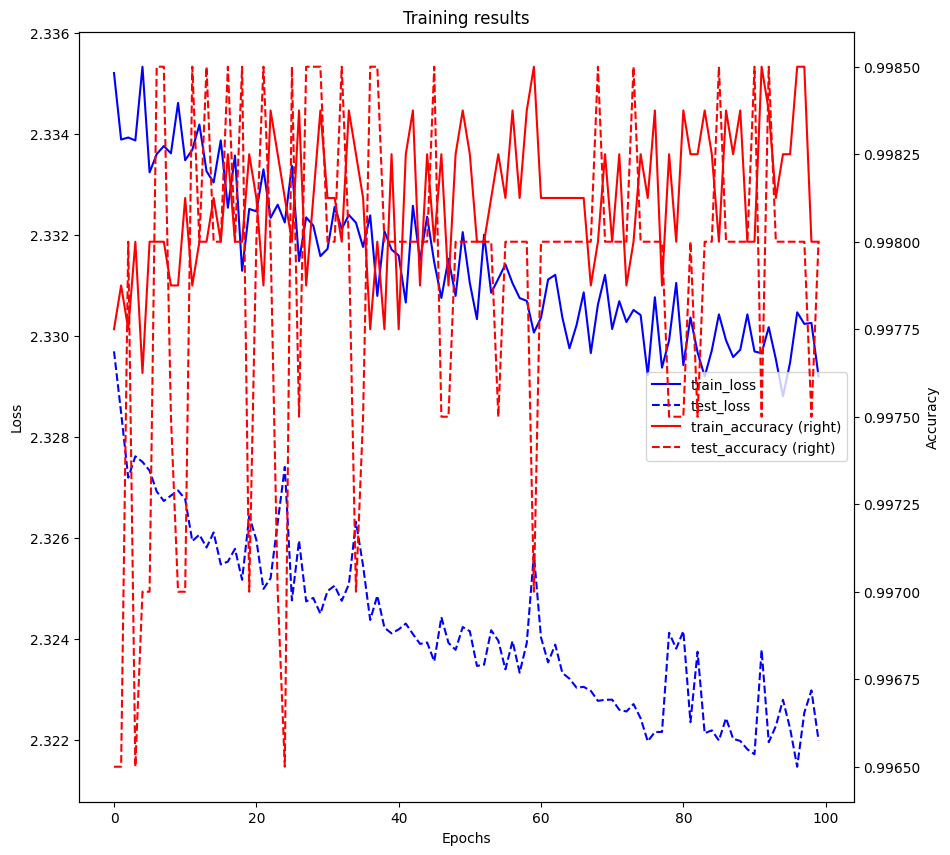

In [10]:
from visualization import plot_training

plot_training(res)